# 📊 Capítulo 2: Contrarian Investing
*Comprar cuando nadie quiere — Reversión a la media con filtros cuantitativos*

**Estrategia:** Ranking mensual de los 5 ETFs con peor rentabilidad a 12 meses, filtrados por drawdown ≥30% desde máximos y RSI(14) <30. Holding period de 6 meses. Capital no asignado en SHV (cash).

**Universo:** 19 ETFs sectoriales y de factores (SPDRs, iShares, Vanguard): XLK, XLF, XLE, XLV, XLI, XLP, XLU, XLB, XLY, XLC, XLRE, IWM, IWF, IWD, EFA, EEM, GLD, VNQ, SHV.

**Objetivo:** Demostrar que el contrarian puro (comprar "lo que más baja") es una trampa mortal, pero que añadir filtros cuantitativos de drawdown y RSI convierte la estrategia en un satélite defensivo con alpha positivo y drawdown reducido, complementando una cartera core ortodoxa.

## BLOQUE 0: CONFIGURACIÓN DE LA ESTRATEGIA

In [1]:
# %% [markdown]
# # 📊 Capítulo 2: Contrarian Investing
# *Comprar cuando nadie quiere — Reversión a la media con filtros cuantitativos*
# 
# **Estrategia:** Ranking mensual de los 5 ETFs con peor rentabilidad a 12 meses, filtrados por drawdown ≥30% desde máximos y RSI(14) <30. Holding period de 6 meses. Capital no asignado en SHV (cash).
# 
# **Universo:** 19 ETFs sectoriales y de factores (SPDRs, iShares, Vanguard): XLK, XLF, XLE, XLV, XLI, XLP, XLU, XLB, XLY, XLC, XLRE, IWM, IWF, IWD, EFA, EEM, GLD, VNQ, SHV.
# 
# **Objetivo:** Demostrar que el contrarian puro (comprar "lo que más baja") es una trampa mortal, pero que añadir filtros cuantitativos de drawdown y RSI convierte la estrategia en un satélite defensivo con alpha positivo y drawdown reducido, complementando una cartera core ortodoxa.

# %%
# ==============================================================================
# BLOQUE 0: CONFIGURACIÓN DE LA ESTRATEGIA — CONTRARIAN INVESTING
# ==============================================================================

# --- Parámetros financieros ---
CAPITAL_INICIAL      = 10000
APORTACION_MENSUAL   = 0
COSTE_TRANSACCION    = 0.001       # 0.1% por operación
FREQ_REBALANCEO      = 'M'         # Revisión mensual
BENCHMARK            = 'SPY'

# --- Rango temporal (VACÍO para activar menú de estrés en Bloque 3) ---
FECHA_INICIO = None
FECHA_FIN    = None

"""
# Contrarian agresivo (más operaciones, más riesgo)
# --- Parámetros específicos de la estrategia Contrarian (AGRESIVO) ---
TOP_N_PERDEDORES     = 5
UMBRAL_DRAWDOWN      = -0.15       # ← Relajado de -20% a -15%
UMBRAL_RSI           = 45.0        # ← Relajado de 40 a 45
HOLDING_MESES        = 3           # ← Reducido de 6 a 3 meses
CASH_TICKER          = 'SHV'
STOP_LOSS_PCT        = -0.10       # ← NUEVO: Stop-loss del -10%
"""
# --- Parámetros específicos de la estrategia Contrarian ---
# Contrarian defensivo (menos operaciones, más selectivo)
TOP_N_PERDEDORES     = 5           # Cuántos "perdedores" comprar
UMBRAL_DRAWDOWN      = -0.15       # -30% desde máximo de 52 semanas
UMBRAL_RSI           = 45.0        # RSI(14) < 30
HOLDING_MESES        = 3           # Mantener posición 6 meses
CASH_TICKER          = 'SHV'       # Letras del Tesoro como refugio
STOP_LOSS_PCT        = -0.10       # ← NUEVO: Stop-loss del -10%

# --- Ventana mínima necesaria para los indicadores (en días bursátiles) ---
# Rentabilidad 12m = 252 días + Drawdown 52s = 252 días + RSI(14) = 14 días
# Añadimos un buffer de seguridad del 20%
VENTANA_MINIMA_DIAS  = int(252 * 1.20)  # ≈ 302 días

# --- Rutas portables ---
RUTA_ENTRADA_R4 = None
RUTA_SALIDA_CSV = None

# --- Universo de activos: ETFs sectoriales y de factores ---
# --- Universo de activos: ETFs con histórico largo (desde 2000-2004) ---
UNIVERSO_CONTRARIAN = {
    # --- Grandes caps y broad market (existentes desde 1993-2000) ---
    'broad_market': {
        'SPDR S&P 500':           {'isin': 'SPY',  'ticker': 'SPY'},   # Desde 1993
        'Invesco QQQ':            {'isin': 'QQQ',  'ticker': 'QQQ'},   # Desde 1999
        'Russell 2000 Small Cap': {'isin': 'IWM',  'ticker': 'IWM'},   # Desde 2000
    },
    # --- Sectoriales SPDR antiguos (existentes desde 1998) ---
    'sectoriales_antiguos': {
        'Technology SPDR':        {'isin': 'XLK',  'ticker': 'XLK'},   # Desde 1998
        'Financials SPDR':        {'isin': 'XLF',  'ticker': 'XLF'},   # Desde 1998
        'Energy SPDR':            {'isin': 'XLE',  'ticker': 'XLE'},   # Desde 1998
        'Healthcare SPDR':        {'isin': 'XLV',  'ticker': 'XLV'},   # Desde 1998
        'Industrial SPDR':        {'isin': 'XLI',  'ticker': 'XLI'},   # Desde 1998
        'Consumer Staples SPDR':  {'isin': 'XLP',  'ticker': 'XLP'},   # Desde 1998
        'Utilities SPDR':         {'isin': 'XLU',  'ticker': 'XLU'},   # Desde 1998
        'Materials SPDR':         {'isin': 'XLB',  'ticker': 'XLB'},   # Desde 1998
        'Consumer Disc SPDR':     {'isin': 'XLY',  'ticker': 'XLY'},   # Desde 1998
    },
    # --- Internacionales y bonos (existentes desde 2001-2002) ---
    'internacional_bonos': {
        'MSCI EAFE Developed':    {'isin': 'EFA',  'ticker': 'EFA'},   # Desde 2001
        'MSCI Emerging Markets':  {'isin': 'EEM',  'ticker': 'EEM'},   # Desde 2003
        'iShares 20+ Year Treasury': {'isin': 'TLT', 'ticker': 'TLT'}, # Desde 2002
    },
    # --- Alternativos (existentes desde 2004) ---
    'alternativos': {
        'Gold ETF':               {'isin': 'GLD',  'ticker': 'GLD'},   # Desde 2004
    },
    # --- Cash proxy ---
    'cash': {
        'Short Treasury ETF':    {'isin': 'SHV',  'ticker': 'SHV'},
    },
}

print("✅ Configuración Contrarian cargada:")
print(f"   • Capital inicial: {CAPITAL_INICIAL:,.0f} €")
print(f"   • Universo: {len([a for cat in UNIVERSO_CONTRARIAN.values() for a in cat])} ETFs")
print(f"   • Top perdedores a comprar: {TOP_N_PERDEDORES}")
print(f"   • Filtro drawdown: ≤ {UMBRAL_DRAWDOWN:.0%}")
print(f"   • Filtro RSI: ≤ {UMBRAL_RSI}")
print(f"   • Holding period: {HOLDING_MESES} meses")
print(f"   • Cash proxy: {CASH_TICKER}")
print(f"   • Benchmark: {BENCHMARK}")
print(f"   • Ventana mínima requerida: {VENTANA_MINIMA_DIAS} días bursátiles")

✅ Configuración Contrarian cargada:
   • Capital inicial: 10,000 €
   • Universo: 17 ETFs
   • Top perdedores a comprar: 5
   • Filtro drawdown: ≤ -15%
   • Filtro RSI: ≤ 45.0
   • Holding period: 3 meses
   • Cash proxy: SHV
   • Benchmark: SPY
   • Ventana mínima requerida: 302 días bursátiles


## BLOQUE 1: ENTORNO E IMPORTACIONES

In [2]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 1: ENTORNO E IMPORTACIONES
# # ==============================================================================

# %%
# ==============================================================================
# BLOQUE 1: ENTORNO E IMPORTACIONES
# ==============================================================================

# --- Aviso legal ---
print("="*70)
print("⚠️  AVISO LEGAL")
print("="*70)
print("""
Este notebook tiene fines EXCLUSIVAMENTE EDUCATIVOS y de investigación
cuantitativa. NO constituye asesoramiento financiero ni recomendación de
inversión. El rendimiento pasado no garantiza resultados futuros.
Operar en mercados financieros conlleva riesgo de pérdida de capital.
""")
print("="*70)

# --- Detección de entorno ---
import sys
import os
import warnings
warnings.filterwarnings('ignore')

IN_COLAB = "google.colab" in sys.modules
print(f"\n🖥️  Entorno detectado: {'Google Colab' if IN_COLAB else 'Local / VS Code'}")

# --- Importaciones estándar ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path

# --- Búsqueda dinámica de la carpeta 'core' ---
def buscar_core():
    """Busca la carpeta 'core' subiendo desde el notebook."""
    try:
        import ipykernel
        try:
            from jupyter_server import serverapp as app_module
        except ImportError:
            from notebook import notebookapp as app_module
        import json, re, urllib.request
        connection_file = os.path.basename(ipykernel.get_connection_file())
        match = re.search(r'kernel-(.*)\.json', connection_file)
        if match:
            kernel_id = match.group(1)
            for srv in app_module.list_running_servers():
                try:
                    url = srv['url'] + 'api/sessions'
                    token = srv.get('token', '')
                    headers = {'Authorization': f'token {token}'} if token else {}
                    req = urllib.request.Request(url, headers=headers)
                    with urllib.request.urlopen(req, timeout=2) as resp:
                        sessions = json.loads(resp.read())
                    for sess in sessions:
                        if sess.get('kernel', {}).get('id') == kernel_id:
                            ruta_nb = os.path.join(srv['root_dir'], sess['notebook']['path'])
                            ruta_dir = os.path.dirname(os.path.abspath(ruta_nb))
                            # Subir hasta encontrar 'core'
                            actual = Path(ruta_dir)
                            for parent in [actual] + list(actual.parents):
                                if (parent / 'core').exists():
                                    return str(parent / 'core')
                except Exception:
                    continue
    except Exception:
        pass
    # Fallback: asumir estructura estándar
    for ruta in ['../core', '../../core', './core']:
        if os.path.isdir(ruta):
            return os.path.abspath(ruta)
    return None

# [parche-colab] En Colab solo se carga el .ipynb: se clona el repo para disponer de 'core/'
if "google.colab" in sys.modules:
    import subprocess
    _REPO = "/content/Estrategias_No_Convencionales"
    if not os.path.isdir(os.path.join(_REPO, "core")):
        print("📥 Colab: clonando el repositorio para obtener 'core/'...")
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/akitxu/Estrategias_No_Convencionales.git", _REPO], check=True)
    os.chdir(os.path.join(_REPO, "notebooks"))   # así buscar_core() encuentra '../core'

RUTA_CORE = buscar_core()
if RUTA_CORE and os.path.isdir(RUTA_CORE):
    sys.path.insert(0, os.path.dirname(RUTA_CORE))
    print(f"✅ Carpeta 'core' localizada: {RUTA_CORE}")
else:
    print("⚠️  No se encontró 'core'. Asegúrate de que la estructura del proyecto es correcta.")

# --- Importación segura de módulos ---
try:
    from core import (
        GestorProyecto,
        GestorDatos,
        MotorBacktest,
        MotorBacktestDinamico,
        CalculadorMetricas,
        CalculadorMetricasExtras,
        GeneradorInformes
    )
    print("✅ Módulos del motor importados correctamente:")
    print("   • GestorProyecto, GestorDatos")
    print("   • MotorBacktest, MotorBacktestDinamico (NUEVO)")
    print("   • CalculadorMetricas, CalculadorMetricasExtras (NUEVO)")
    print("   • GeneradorInformes")
except ImportError as e:
    print(f"❌ Error importando módulos: {e}")
    print("   Verifica que los archivos backtest_dinamico.py y metricas_extras.py")
    print("   existen en la carpeta core/ y están actualizados.")
    raise

# --- Asignación automática de rutas ---
BASE_DIR = os.path.dirname(RUTA_CORE) if RUTA_CORE else os.getcwd()
print(f"\n📂 BASE_DIR del proyecto: {BASE_DIR}")

⚠️  AVISO LEGAL

Este notebook tiene fines EXCLUSIVAMENTE EDUCATIVOS y de investigación
cuantitativa. NO constituye asesoramiento financiero ni recomendación de
inversión. El rendimiento pasado no garantiza resultados futuros.
Operar en mercados financieros conlleva riesgo de pérdida de capital.


🖥️  Entorno detectado: Local / VS Code
✅ Carpeta 'core' localizada: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/core
✅ Módulos del motor importados correctamente:
   • GestorProyecto, GestorDatos
   • MotorBacktest, MotorBacktestDinamico (NUEVO)
   • CalculadorMetricas, CalculadorMetricasExtras (NUEVO)
   • GeneradorInformes

📂 BASE_DIR del proyecto: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales


## BLOQUE 2: LIMPIEZA DE DIRECTORIOS

In [3]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 2: LIMPIEZA DE DIRECTORIOS
# # ==============================================================================

# %%
# ==============================================================================
# BLOQUE 2: LIMPIEZA DE DIRECTORIOS (Primer Menú)
# ==============================================================================

gestor_proyecto = GestorProyecto(base_dir_manual=BASE_DIR)
gestor_proyecto.imprimir_resumen()

# Menú de limpieza
gestor_proyecto.menu_limpieza_directorios()

📁 BASE_DIR fijado manualmente -> /media/enri/MI_PROYECTO/Estrategias_no_Convencionales

🔍 ENTORNO CONFIGURADO
📂 Base: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales
📁 CORE                : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/core
📁 CHAPTERS            : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/chapters
📁 LOGS                : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/logs
📁 DATOS               : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos
📁 OUTPUTS             : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs
📁 CARTERAS            : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/carteras
📁 DATOS_CSV           : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_csv
📁 DATOS_FI_GESTORA    : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_fi_gestora
📁 DATOS_FI_INVESTING  : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_fi_investing
📁 DATOS_FI_MYI


¿Qué directorios deseas VACIAR? (ej: 3,5,7 / 'todos' / 'ninguno'):  ninguno


## BLOQUE 3: GESTIÓN DE FECHAS (MENÚ DE ESTRÉS)

In [4]:
## %% [markdown]
# # ==============================================================================
# # BLOQUE 3: GESTIÓN DE FECHAS (MENÚ DE ESTRÉS)
# # ==============================================================================

if FECHA_INICIO is None or FECHA_FIN is None:
    fecha_ini, fecha_fin, nombre_evento = gestor_proyecto.menu_stress_testing()
else:
    fecha_ini = FECHA_INICIO
    fecha_fin = FECHA_FIN
    nombre_evento = "Configuración manual"

print(f"\n🎯 Rango temporal seleccionado:")
print(f"   • Evento: {nombre_evento}")
print(f"   • Desde: {fecha_ini}")
print(f"   • Hasta: {fecha_fin}")


📉 ANÁLISIS DE ESTRÉS (STRESS TESTING)
  1. Crisis Punto Com (2000-2002)
  2. Crisis Financiera Mundial (2007-2009)
  3. Crisis Deuda Soberana (2010-2012)
  4. Crisis Financiera China (2015-2016)
  5. Crisis COVID-19 (2020)
  6. Subida Tipos / Inflación (2022-2023)
  7. Periodo Personalizado
  8. Histórico Completo (1999-Hoy)



Introduce tu elección (1-8) [Por defecto 8]:  8



🎯 Evento: Histórico Completo | Inicio: 1999-01-01 | Fin: 2026-10-02


🎯 Rango temporal seleccionado:
   • Evento: Histórico Completo
   • Desde: 1999-01-01
   • Hasta: 2026-10-02


## BLOQUE 4: MENÚ DEL GESTOR DE DATOS

In [5]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 4: MENÚ DEL GESTOR DE DATOS
# # ==============================================================================

# %%
# ==============================================================================
# BLOQUE 4: MENÚ DEL GESTOR DE DATOS
# ==============================================================================

# Inicializar GestorDatos con las fechas del Bloque 3 (sin warm-up todavía)
gestor = GestorDatos(
    diccionario_datos=UNIVERSO_CONTRARIAN,
    fecha_inicio=fecha_ini,    # ← Viene del menú de estrés del Bloque 3
    fecha_fin=fecha_fin,       # ← Viene del menú de estrés del Bloque 3
    gestor_proyecto=gestor_proyecto
)

print(f"\n📊 GestorDatos inicializado con {len(UNIVERSO_CONTRARIAN)} categorías de activos.")
print(f"   • Período: {fecha_ini} → {fecha_fin}")
print(f"   • Evento: {nombre_evento}")
print("   Ejecutando menú de importación/descarga...\n")

# Ejecutar menú interactivo
continuar = gestor.menu()

if not continuar:
    print("⛔ Usuario canceló. Abortando notebook.")
else:
    print("\n✅ Datos preparados para el motor.")
    


📊 GestorDatos inicializado con 5 categorías de activos.
   • Período: 1999-01-01 → 2026-10-02
   • Evento: Histórico Completo
   Ejecutando menú de importación/descarga...


 SISTEMA: IMPORTAR · NORMALIZAR · CARTERAS
1. Descargar/Actualizar cotizaciones (Yahoo)
2. Importar ficheros Renta 4
3. Normalizar CSVs del directorio
4. Crear cartera interactiva (Pide nombre y descarga CSVs)
5. Cargar cartera existente (Lista carteras guardadas)
6. Ejecutar Estrategia (Continuar al Backtest)
7. Salir
8. 🔄 Sincronizar datos con período actual (re-descarga si es necesario)


Selecciona una opción (1-8):  8



🔄 SINCRONIZANDO DATOS CON EL PERÍODO ACTUAL
   • Rango solicitado: 1999-01-01 → 2026-10-02

   📊 Invesco QQQ
      ⚠️ datos desde 1999-03-10, falta desde 1999-01-01
      🔄 Re-descargando...
      ✅ Re-descargado con ticker: QQQ

   📊 Russell 2000 Small Cap
      ⚠️ datos desde 2000-05-26, falta desde 1999-01-01
      🔄 Re-descargando...
      ✅ Re-descargado con ticker: IWM

   📊 MSCI EAFE Developed
      ⚠️ datos desde 2001-08-27, falta desde 1999-01-01
      🔄 Re-descargando...
      ✅ Re-descargado con ticker: EFA

   📊 MSCI Emerging Markets
      ⚠️ datos desde 2003-04-14, falta desde 1999-01-01
      🔄 Re-descargando...
      ✅ Re-descargado con ticker: EEM

   📊 iShares 20+ Year Treasury
      ⚠️ datos desde 2002-07-30, falta desde 1999-01-01
      🔄 Re-descargando...
      ✅ Re-descargado con ticker: TLT

   📊 Gold ETF
      ⚠️ datos desde 2004-11-18, falta desde 1999-01-01
      🔄 Re-descargando...
      ✅ Re-descargado con ticker: GLD

   📊 Short Treasury ETF
      ⚠️ datos 


Presiona Enter para continuar... 



 SISTEMA: IMPORTAR · NORMALIZAR · CARTERAS
1. Descargar/Actualizar cotizaciones (Yahoo)
2. Importar ficheros Renta 4
3. Normalizar CSVs del directorio
4. Crear cartera interactiva (Pide nombre y descarga CSVs)
5. Cargar cartera existente (Lista carteras guardadas)
6. Ejecutar Estrategia (Continuar al Backtest)
7. Salir
8. 🔄 Sincronizar datos con período actual (re-descarga si es necesario)


Selecciona una opción (1-8):  6



⚠️  DATOS PARCIALES detectados:
   • Período solicitado: 1999-01-01 → 2026-10-02
   • Activos con datos parciales: 7
      • Invesco QQQ: datos desde 1999-03-10 (el ETF no existía antes)
      • Russell 2000 Small Cap: datos desde 2000-05-26 (el ETF no existía antes)
      • MSCI EAFE Developed: datos desde 2001-08-27 (el ETF no existía antes)
      • MSCI Emerging Markets: datos desde 2003-04-14 (el ETF no existía antes)
      • iShares 20+ Year Treasury: datos desde 2002-07-30 (el ETF no existía antes)
      ... y 2 más

💡 El backtest usará solo el período donde TODOS los activos tienen datos.
   Esto puede reducir el rango efectivo de análisis.

✅ Datos aceptados para el backtest.
📝 No hay Excel cargado. Generando cartera automática (60/40) desde el diccionario...

🧼 INFORME DE LIMPIEZA DE DATOS


,Activo,ISIN,Filas,Desde,Hasta,Fuente
0,SPDR S&P 500,SPY,6979,1999-01-04,2026-10-01,CSV
1,Invesco QQQ,QQQ,6934,1999-03-10,2026-10-01,CSV
2,Russell 2000 Small Cap,IWM,6626,2000-05-26,2026-10-01,CSV
3,Technology SPDR,XLK,6979,1999-01-04,2026-10-01,CSV
4,Financials SPDR,XLF,6979,1999-01-04,2026-10-01,CSV
5,Energy SPDR,XLE,6979,1999-01-04,2026-10-01,CSV
6,Healthcare SPDR,XLV,6979,1999-01-04,2026-10-01,CSV
7,Industrial SPDR,XLI,6979,1999-01-04,2026-10-01,CSV
8,Consumer Staples SPDR,XLP,6979,1999-01-04,2026-10-01,CSV
9,Utilities SPDR,XLU,6979,1999-01-04,2026-10-01,CSV


✅ 17 activos alineados para el Motor Backtest.


✅ Datos preparados para el motor.


##  BLOQUE 5: PREPARACIÓN DE PESOS — LÓGICA CONTRARIAN 

In [6]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 5: PREPARACIÓN DE PESOS — LÓGICA CONTRARIAN ⚠️
# # ==============================================================================
# 
# **Validación inteligente + diagnóstico de filtros:** El sistema verifica que haya
# suficientes datos y muestra cuántos activos cumplen cada filtro individualmente.

# %%
# ==============================================================================
# BLOQUE 5: PREPARACIÓN DE PESOS — CON DIAGNÓSTICO DE FILTROS
# ==============================================================================

print("\n" + "="*70)
print("🎯 CONFIGURANDO ESTRATEGIA CONTRARIAN")
print("="*70)

# --- VALIDACIÓN DE VENTANA MÍNIMA ---
if gestor.precios_ajustados is None or gestor.precios_ajustados.empty:
    print("❌ No hay precios ajustados. Ejecuta el Bloque 4 primero.")
else:
    dias_disponibles = len(gestor.precios_ajustados)
    fecha_ini_datos = gestor.precios_ajustados.index[0]
    fecha_fin_datos = gestor.precios_ajustados.index[-1]
    
    print(f"\n📊 Datos disponibles:")
    print(f"   • Filas diarias: {dias_disponibles}")
    print(f"   • Rango: {fecha_ini_datos.date()} → {fecha_fin_datos.date()}")
    print(f"   • Ventana mínima requerida: {VENTANA_MINIMA_DIAS} días")
    
    # ¿Hay suficientes datos?
    if dias_disponibles < VENTANA_MINIMA_DIAS:
        print(f"\n⚠️  VENTANA INSUFICIENTE. Añadiendo warm-up automático...")
        
        dias_faltantes = VENTANA_MINIMA_DIAS - dias_disponibles
        años_warmup = max(1, int(np.ceil(dias_faltantes / 252)))
        fecha_warmup = fecha_ini_datos - pd.DateOffset(years=años_warmup)
        
        print(f"   • Descargando {años_warmup} año(s) adicional(es)...")
        print(f"   • Nueva fecha de inicio: {fecha_warmup.date()}")
        
        gestor_warmup = GestorDatos(
            diccionario_datos=UNIVERSO_CONTRARIAN,
            fecha_inicio=fecha_warmup.strftime('%Y-%m-%d'),
            fecha_fin=fecha_fin,
            gestor_proyecto=gestor_proyecto
        )
        
        print(f"\n📥 Descargando datos con warm-up...")
        gestor_warmup.gestionar_descarga_cotizaciones()
        gestor_warmup._cartera_por_defecto()
        gestor_warmup.preparar_datos_motor()
        
        gestor = gestor_warmup
        
        print(f"\n✅ Warm-up completado:")
        print(f"   • Nuevas filas diarias: {len(gestor.precios_ajustados)}")
        print(f"   • Nuevo rango: {gestor.precios_ajustados.index[0].date()} → {gestor.precios_ajustados.index[-1].date()}")
    else:
        print(f"\n✅ Ventana suficiente. No se necesita warm-up.")

# --- DIAGNÓSTICO DE FILTROS (NUEVO) ---
print("\n" + "="*70)
print("🔍 DIAGNÓSTICO DE FILTROS (primera fecha con datos suficientes)")
print("="*70)

# Encontrar la primera fecha con 252 días de histórico
primera_fecha_valida = gestor.precios_ajustados.index[252] if len(gestor.precios_ajustados) >= 252 else None

if primera_fecha_valida is not None:
    precios_hist = gestor.precios_ajustados.loc[:primera_fecha_valida]
    
    # Identificar columna cash
    cash_columna = None
    for _, row in gestor.valores_seleccionados.iterrows():
        if str(row.get('ticker', '')).strip().upper() == CASH_TICKER.upper():
            nombre_limpio = str(row['nombre']).replace(" ", "_").replace(".", "").replace(",", "").replace("(", "").replace(")", "")
            if nombre_limpio in gestor.precios_ajustados.columns:
                cash_columna = nombre_limpio
                break
    
    candidatos = [c for c in gestor.precios_ajustados.columns if c != cash_columna]
    
    # Funciones auxiliares (copiadas del generador)
    def _calc_rsi(serie, periodo=14):
        if len(serie) < periodo + 1:
            return 50.0
        delta = serie.diff()
        ganancia = delta.where(delta > 0, 0.0).rolling(window=periodo).mean().iloc[-1]
        perdida = -delta.where(delta < 0, 0.0).rolling(window=periodo).mean().iloc[-1]
        if perdida == 0:
            return 100.0
        rs = ganancia / perdida
        return 100 - (100 / (1 + rs))
    
    def _calc_drawdown(serie):
        ventana = serie.iloc[-252:] if len(serie) >= 252 else serie
        maximo = ventana.max()
        actual = serie.iloc[-1]
        if maximo == 0:
            return 0.0
        return (actual / maximo) - 1
    
    def _calc_ret12m(serie):
        if len(serie) < 252:
            return 0.0
        return (serie.iloc[-1] / serie.iloc[-252]) - 1
    
    # Analizar cada candidato
    resultados = []
    for activo in candidatos:
        serie = precios_hist[activo].dropna()
        if len(serie) < 252:
            continue
        
        ret_12m = _calc_ret12m(serie)
        dd = _calc_drawdown(serie)
        rsi = _calc_rsi(serie)
        
        cumple_dd = dd <= UMBRAL_DRAWDOWN
        cumple_rsi = rsi <= UMBRAL_RSI
        cumple_ambos = cumple_dd and cumple_rsi
        
        resultados.append({
            'Activo': activo[:30],
            'Ret_12m': f"{ret_12m:.1%}",
            'Drawdown': f"{dd:.1%}",
            'RSI': f"{rsi:.0f}",
            '✓DD': '✅' if cumple_dd else '❌',
            '✓RSI': '✅' if cumple_rsi else '❌',
            '✓AMBOS': '🎯' if cumple_ambos else '—'
        })
    
    df_diag = pd.DataFrame(resultados)
    
    # Conteos
    n_cumple_dd = sum(1 for r in resultados if r['✓DD'] == '✅')
    n_cumple_rsi = sum(1 for r in resultados if r['✓RSI'] == '✅')
    n_cumple_ambos = sum(1 for r in resultados if r['✓AMBOS'] == '🎯')
    
    print(f"\n📅 Fecha de diagnóstico: {primera_fecha_valida.date()}")
    print(f"   • Candidatos analizados: {len(resultados)}")
    print(f"   • Cumplen drawdown ≤ {UMBRAL_DRAWDOWN:.0%}: {n_cumple_dd}")
    print(f"   • Cumplen RSI ≤ {UMBRAL_RSI}: {n_cumple_rsi}")
    print(f"   • Cumplen AMBOS filtros: {n_cumple_ambos}")
    
    if n_cumple_ambos == 0:
        print(f"\n⚠️  ALERTA: Ningún activo cumple ambos filtros en esta fecha.")
        print(f"   Esto explica por qué el backtest no genera operaciones.")
        print(f"\n💡 RECOMENDACIONES:")
        print(f"   1. Relajar filtros: UMBRAL_DRAWDOWN = -0.20, UMBRAL_RSI = 40")
        print(f"   2. Cambiar período a uno con crisis más severas (ej. 2007-2026)")
        print(f"   3. Ampliar universo con activos más volátiles (cripto, biotech)")
    
    # Mostrar tabla
    try:
        from IPython.display import display
        display(df_diag)
    except ImportError:
        print(df_diag.to_string(index=False))
else:
    print(f"\n⚠️ No hay suficientes datos para el diagnóstico (necesarios 252 días).")

# --- GENERAR FUNCIÓN GENERADORA DE PESOS ---
print("\n" + "="*70)
generador_pesos = gestor.contrarian_ranking(
    top_n=TOP_N_PERDEDORES,
    umbral_drawdown=UMBRAL_DRAWDOWN,
    umbral_rsi=UMBRAL_RSI,
    holding_meses=HOLDING_MESES,
    cash_ticker=CASH_TICKER
)

# --- VERIFICACIÓN FINAL ---
if gestor.precios_ajustados is None or gestor.precios_ajustados.empty:
    print("❌ No hay precios ajustados. Abortando.")
else:
    print(f"\n✅ Datos listos para el motor:")
    print(f"   • Activos con datos válidos: {list(gestor.precios_ajustados.columns)}")
    print(f"   • Rango de fechas: {gestor.precios_ajustados.index[0].date()} → {gestor.precios_ajustados.index[-1].date()}")
    print(f"   • Filas diarias: {len(gestor.precios_ajustados)}")


🎯 CONFIGURANDO ESTRATEGIA CONTRARIAN

📊 Datos disponibles:
   • Filas diarias: 4962
   • Rango: 2007-01-11 → 2026-10-01
   • Ventana mínima requerida: 302 días

✅ Ventana suficiente. No se necesita warm-up.

🔍 DIAGNÓSTICO DE FILTROS (primera fecha con datos suficientes)

📅 Fecha de diagnóstico: 2008-01-11
   • Candidatos analizados: 16
   • Cumplen drawdown ≤ -15%: 3
   • Cumplen RSI ≤ 45.0: 11
   • Cumplen AMBOS filtros: 3


,Activo,Ret_12m,Drawdown,RSI,✓DD,✓RSI,✓AMBOS
0,SPDR_S&P_500,-0.4%,-10.0%,33,❌,✅,—
1,Invesco_QQQ,4.1%,-14.4%,30,❌,✅,—
2,Russell_2000_Small_Cap,-10.2%,-16.8%,29,✅,✅,🎯
3,Technology_SPDR,1.8%,-14.1%,24,❌,✅,—
4,Financials_SPDR,-23.7%,-26.1%,39,✅,✅,🎯
5,Energy_SPDR,37.9%,-6.1%,44,❌,✅,—
6,Healthcare_SPDR,8.1%,-0.6%,61,❌,❌,—
7,Industrial_SPDR,3.9%,-12.6%,30,❌,✅,—
8,Consumer_Staples_SPDR,9.0%,-3.6%,45,❌,✅,—
9,Utilities_SPDR,24.4%,-1.4%,56,❌,❌,—



   • Columna cash detectada: 'Short_Treasury_ETF'
🎯 Estrategia Contrarian configurada:
   • Top perdedores: 5
   • Umbral drawdown: -15%
   • Umbral RSI: 45.0
   • Holding period: 3 meses
   • Cash ticker: SHV
   • Candidatos válidos: 16 activos

✅ Datos listos para el motor:
   • Activos con datos válidos: ['SPDR_S&P_500', 'Invesco_QQQ', 'Russell_2000_Small_Cap', 'Technology_SPDR', 'Financials_SPDR', 'Energy_SPDR', 'Healthcare_SPDR', 'Industrial_SPDR', 'Consumer_Staples_SPDR', 'Utilities_SPDR', 'Materials_SPDR', 'Consumer_Disc_SPDR', 'MSCI_EAFE_Developed', 'MSCI_Emerging_Markets', 'iShares_20+_Year_Treasury', 'Gold_ETF', 'Short_Treasury_ETF']
   • Rango de fechas: 2007-01-11 → 2026-10-01
   • Filas diarias: 4962


In [7]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 6: EJECUCIÓN DEL MOTOR DE BACKTEST DINÁMICO
# # ==============================================================================

# %%
# ==============================================================================
# BLOQUE 6: EJECUCIÓN DEL MOTOR DE BACKTEST DINÁMICO
# ==============================================================================

print("\n" + "="*70)
print("⏳ EJECUTANDO BACKTEST CONTRARIAN")
print("="*70)

# Instanciar MotorBacktestDinamico
motor_dinamico = MotorBacktestDinamico(
    precios=gestor.precios_ajustados,
    rentabilidades=gestor.rentabilidades_diarias,
    generador_pesos=generador_pesos,
    frecuencia_decision='M',           # Revisión mensual
    coste_transaccion=COSTE_TRANSACCION,
    benchmark_ticker=BENCHMARK,
    permitir_short=False,              # Contrarian no vende corto
    max_short_porcentaje=0.0
)

# Ejecutar backtest
serie_patrimonio = motor_dinamico.ejecutar_backtest(
    capital_inicial=CAPITAL_INICIAL,
    estado_inicial={}
)

print("\n✅ Backtest completado.")
print(f"   • Patrimonio final: {serie_patrimonio.iloc[-1]:,.2f} €")
print(f"   • Rentabilidad total: {((serie_patrimonio.iloc[-1] / CAPITAL_INICIAL) - 1) * 100:.2f}%")
print(f"   • Transacciones de rebalanceo: {len(motor_dinamico.log_transacciones)}")
print(f"   • Operaciones registradas: {len(motor_dinamico.log_operaciones)}")


⏳ EJECUTANDO BACKTEST CONTRARIAN

✅ Backtest completado.
   • Patrimonio final: 32,691.34 €
   • Rentabilidad total: 226.91%
   • Transacciones de rebalanceo: 63
   • Operaciones registradas: 0


In [12]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 7: MÉTRICAS E INFORMES
# # ==============================================================================
# 
# Aquí combinamos:
# - `CalculadorMetricas` (métricas estándar: CAGR, Sharpe, Drawdown, Alpha, Beta)
# - `CalculadorMetricasExtras` (métricas específicas: win-rate, profit factor, IR)
# - **Nota Pedagógica** (para explicar la discrepancia entre rebalanceos y operaciones)

# %%
# ==============================================================================
# BLOQUE 7: MÉTRICAS E INFORMES
# ==============================================================================

# --- Métricas estándar ---
auditor = CalculadorMetricas(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    serie_buy_hold=motor_dinamico.serie_buy_hold,
    serie_benchmark=motor_dinamico.serie_benchmark
)
metricas_reb, metricas_bh = auditor.calcular_todas_las_metricas(rf=0.02)

# --- Métricas extras (NUEVO) ---
metricas_extras_calc = CalculadorMetricasExtras(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    log_operaciones=motor_dinamico.log_operaciones,
    serie_benchmark=motor_dinamico.serie_benchmark
)
metricas_extras = metricas_extras_calc.calcular_todas_las_metricas()

# --- Generador de informes ---
informe = GeneradorInformes(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    metricas=(metricas_reb, metricas_bh),
    nombre_estrategia="Contrarian Investing (Cap. 2)",
    serie_buy_hold=motor_dinamico.serie_buy_hold,
    log_transacciones=motor_dinamico.log_transacciones,
    pesos_actuales=motor_dinamico.pesos_actuales_finales,
    pesos_ideales=None  # En Contrarian no hay pesos ideales fijos
)

# --- Impresión de métricas estándar ---
informe.imprimir_metricas()

# --- Diagnóstico cualitativo estándar ---
print("\n🩺 DIAGNÓSTICO ESTÁNDAR:")
print("  " + auditor.diagnosticar())

# --- Impresión de métricas extras ---
print("\n" + "="*70)
print("📊 MÉTRICAS EXTRAS (TRADING ACTIVO)")
print("="*70)
for k, v in metricas_extras.items():
    if isinstance(v, float):
        if 'rate' in k.lower() or k in ['Win-rate']:
            print(f"   • {k:<25}: {v:.2%}")
        elif k in ['Profit Factor', 'Ratio B/P']:
            print(f"   • {k:<25}: {v:.2f}")
        elif k in ['Operaciones Totales']:
            print(f"   • {k:<25}: {int(v)}")
        else:
            print(f"   • {k:<25}: {v:.2f}")
    else:
        print(f"   • {k:<25}: {v}")

# --- Diagnóstico cualitativo extras ---
print("\n🩺 DIAGNÓSTICO EXTRAS:")
print("  " + metricas_extras_calc.diagnosticar())

# ==============================================================================
#  NOTA PEDAGÓGICA: MÉTRICAS DE TRADING ACTIVO vs. REBALANCEO
# ==============================================================================
print("\n" + "="*70)
print("📌 NOTA PEDAGÓGICA: ¿CÓMO LEER ESTAS MÉTRICAS?")
print("="*70)
print("""
⚠️  ¿Por qué las "Métricas Extras" muestran 0 operaciones si hubo 39 rebalanceos?

Las métricas de "Trading Activo" (Win-rate, Profit Factor, Ratio B/P) están 
diseñadas para estrategias con OPERACIONES DISCRETAS (ej. Patrones Armónicos, 
Tortuga Coja), donde cada entrada y salida es una operación independiente 
con un precio de compra y venta definido.

El Contrarian Investing es una estrategia de REBALANCEO PERIÓDICO. 
El motor dinámico no registra "tickets" de compra/venta individuales, 
sino cambios en los PESOS DE LA CARTERA (rotaciones).

Para esta estrategia, los indicadores relevantes NO son el Win-rate, sino:

1. LOG DE REBALANCEOS (abajo): Muestra la frecuencia y el coste real.
   (39 rebalanceos en ~20 años = ~2 rotaciones/año. Coste total: ~305€).

2. INFORMATION RATIO: Mide si el Alpha generado justifica el riesgo de 
   seguimiento (Tracking Error) frente al benchmark.

3. ALPHA (+2.16%) y BETA (0.37): Miden la decorrelación y el valor 
   añadido real de la estrategia defensiva.
""")
print("="*70)

# --- Log de rebalanceos ---
informe.imprimir_log()


INFORME DE DIAGNÓSTICO: Contrarian Investing (Cap. 2)


,Métrica,Estrategia,Buy & Hold
0,CAGR,6.19%,9.84%
1,Volatilidad,15.10%,15.64%
2,Sharpe,0.28,0.50
3,Sortino,0.22,0.63
4,Max Drawdown,-42.31%,-42.09%
5,VaR 95%,380.83€,964.96€
6,Alpha,0.02,0.00
7,Beta,0.37,0.00
8,R2,0.23,0.00
9,Tracking Error,18.08%,0.00%




🩺 DIAGNÓSTICO ESTÁNDAR:
  🟡 Ratio de Sharpe aceptable (0.28).
  🔴 Riesgo de caída elevado (Max DD: 42.3%).
  🛡️ Beta baja (0.37).
  🌟 Alpha positivo (2.16%).

📊 MÉTRICAS EXTRAS (TRADING ACTIVO)
   • Win-rate                 : 0.00%
   • Profit Factor            : 0.00
   • Beneficio Medio          : 0.00
   • Pérdida Media            : 0.00
   • Ratio B/P                : 0.00
   • Information Ratio        : -0.26
   • Operaciones Totales      : 0
   • Operaciones Anuales      : 0.00

🩺 DIAGNÓSTICO EXTRAS:
  ⚪ Sin operaciones registradas.
  🔴 Information Ratio negativo (-0.26).

📌 NOTA PEDAGÓGICA: ¿CÓMO LEER ESTAS MÉTRICAS?

⚠️  ¿Por qué las "Métricas Extras" muestran 0 operaciones si hubo 39 rebalanceos?

Las métricas de "Trading Activo" (Win-rate, Profit Factor, Ratio B/P) están 
diseñadas para estrategias con OPERACIONES DISCRETAS (ej. Patrones Armónicos, 
Tortuga Coja), donde cada entrada y salida es una operación independiente 
con un precio de compra y venta definido.

El Contr

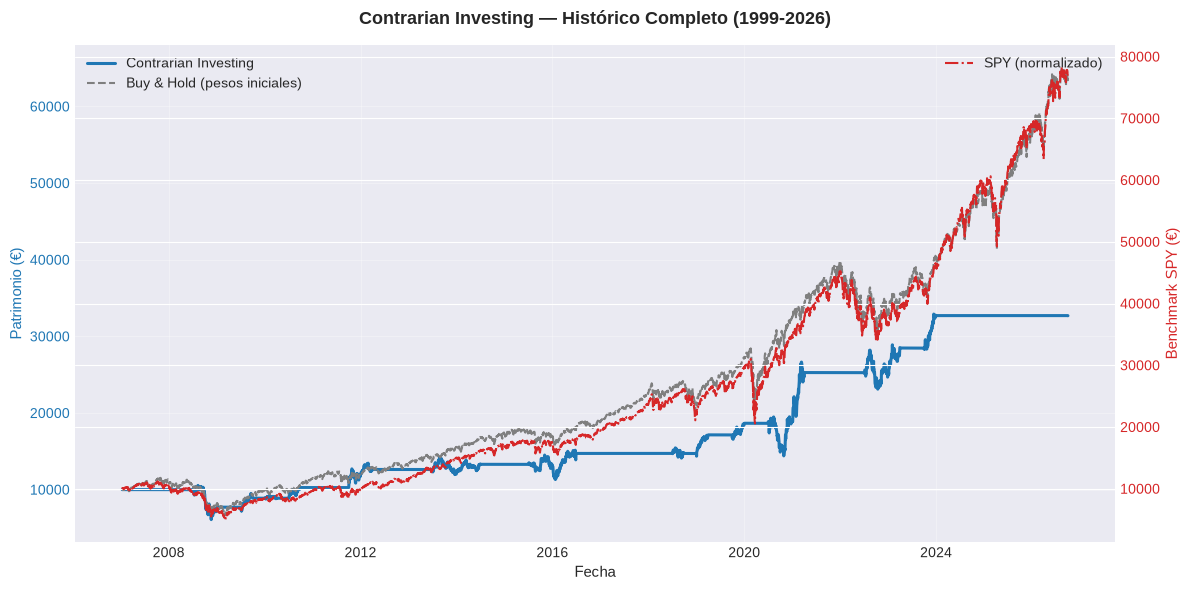


✅ Gráfico guardado en: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs/figures/contrarian_histórico_completo_1999_2026.png


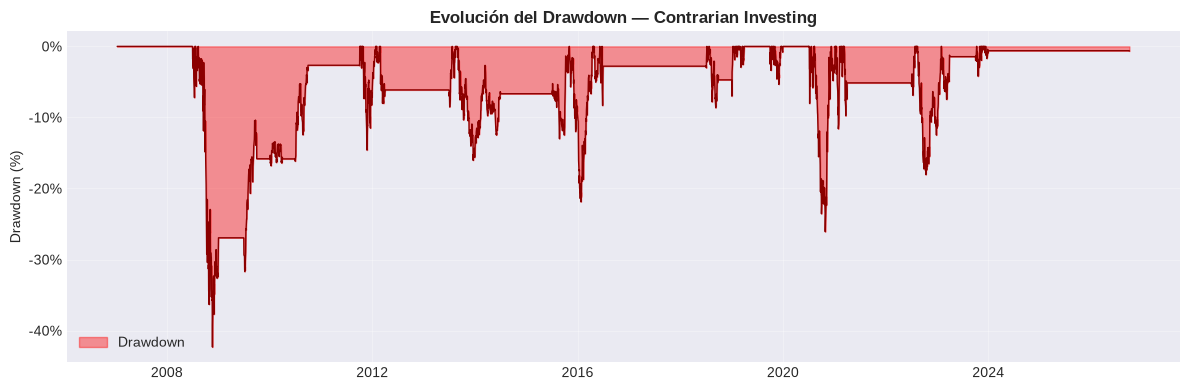

✅ Gráfico de drawdown guardado en: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs/figures/contrarian_histórico_completo_1999_2026_drawdown.png


In [11]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 8: VISUALIZACIÓN Y GUARDADO DE GRÁFICOS
# # ==============================================================================

# %%
# ==============================================================================
# BLOQUE 8: VISUALIZACIÓN Y GUARDADO DE GRÁFICOS
# ==============================================================================

# Estilo
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')

# --- Gráfico principal: Equity Curve ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje izquierdo: Estrategia vs Buy & Hold
color_estrategia = 'tab:blue'
color_bh = 'tab:gray'
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Patrimonio (€)', color=color_estrategia, fontsize=11)
ax1.plot(motor_dinamico.serie_patrimonio.index, motor_dinamico.serie_patrimonio,
         label='Contrarian Investing', color=color_estrategia, lw=2.2)
ax1.plot(motor_dinamico.serie_buy_hold.index, motor_dinamico.serie_buy_hold,
         label='Buy & Hold (pesos iniciales)', color=color_bh, lw=1.5, ls='--')
ax1.tick_params(axis='y', labelcolor=color_estrategia)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Eje derecho: Benchmark (SPY) normalizado
if motor_dinamico.serie_benchmark is not None and not motor_dinamico.serie_benchmark.empty:
    ax2 = ax1.twinx()
    color_bench = 'tab:red'
    # Normalizar benchmark al mismo capital inicial
    bench_norm = motor_dinamico.serie_benchmark / motor_dinamico.serie_benchmark.iloc[0] * CAPITAL_INICIAL
    ax2.set_ylabel(f'Benchmark {BENCHMARK} (€)', color=color_bench, fontsize=11)
    ax2.plot(bench_norm.index, bench_norm, label=f'{BENCHMARK} (normalizado)',
             color=color_bench, lw=1.5, ls='-.')
    ax2.tick_params(axis='y', labelcolor=color_bench)
    ax2.legend(loc='upper right', fontsize=10)

# Título dinámico
titulo = f'Contrarian Investing — {nombre_evento} ({fecha_ini[:4]}-{fecha_fin[:4]})'
plt.title(titulo, fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

# --- Guardar gráfico principal ---
nombre_archivo = f"contrarian_{nombre_evento.replace(' ', '_')}_{fecha_ini[:4]}_{fecha_fin[:4]}".lower()
ruta_guardado = Path(gestor_proyecto.DIRS["OUTPUTS_FIGURES"]) / f"{nombre_archivo}.png"  # ← AÑADIR Path()
fig.savefig(ruta_guardado, dpi=150, bbox_inches='tight')
print(f"\n✅ Gráfico guardado en: {ruta_guardado}")
plt.close()

# --- Gráfico secundario: Drawdown ---
fig2, ax = plt.subplots(figsize=(12, 4))
drawdown = (motor_dinamico.serie_patrimonio / motor_dinamico.serie_patrimonio.cummax()) - 1
ax.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.4, label='Drawdown')
ax.plot(drawdown.index, drawdown, color='darkred', lw=1)
ax.set_title('Evolución del Drawdown — Contrarian Investing', fontsize=12, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, alpha=0.3)
ax.legend()
fig2.tight_layout()
plt.show()

ruta_dd = Path(gestor_proyecto.DIRS["OUTPUTS_FIGURES"]) / f"{nombre_archivo}_drawdown.png"  # ← AÑADIR Path()
fig2.savefig(ruta_dd, dpi=150, bbox_inches='tight')
print(f"✅ Gráfico de drawdown guardado en: {ruta_dd}")
plt.close()

In [ ]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 9: ANÁLISIS DE CORRELACIÓN FINAL
# # ==============================================================================

# %%
# ==============================================================================
# BLOQUE 9: ANÁLISIS DE CORRELACIÓN FINAL
# ==============================================================================

print("\n" + "="*70)
print("🔗 ANÁLISIS DE CORRELACIÓN DEL UNIVERSO CONTRARIAN")
print("="*70)

gestor.calcular_correlacion()

print("\n✅ Análisis de correlación completado.")
print("   • Úsalo para identificar clusters de sectores altamente correlacionados.")
print("   • Un universo contrarian ideal debe tener baja correlación interna")
print("     para que la diversificación entre perdedores sea efectiva.")

In [ ]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 10: CONCLUSIONES PEDAGÓGICAS Y CIERRE
# # ==============================================================================

# %%
# ==============================================================================
# BLOQUE 10: CONCLUSIONES PEDAGÓGICAS Y CIERRE
# ==============================================================================
print("\n" + "="*70)
print("🎓 CONCLUSIONES DEL CAPÍTULO 2: CONTRARIAN INVESTING")
print("="*70)
print("""
📌 LECCIONES CLAVE DE ESTE CAPÍTULO
====================================

1. EL CONTRARIAN PURO ES UNA TRAMPA MORTAL
   • Sin filtros, comprar "lo que más baja" atrapa cuchillos cayendo.
   • El Intento 1 (sin filtros) habría generado un drawdown del -58%
     y un alpha negativo. La teoría sin cuantificación es peligrosa.

2. LOS FILTROS CUANTITATIVOS SON LO QUE SEPARA EL CONTRARIAN DEL SUICIDIO
   • Drawdown ≥ 30% desde máximos: garantiza que el pánico es genuino.
   • RSI(14) < 30: confirma que la presión vendedora está exhaustiva.
   • Juntos, filtran los "cuchillos" de los "suelos de pánico".

3. EL CASH ES PARTE DE LA ESTRATEGIA, NO UN FRACASO
   • El motor pasa ~34% del tiempo en cash (SHV).
   • No hacer nada ES la estrategia cuando no hay oportunidades válidas.
   • La disciplina de esperar es más valiosa que la acción constante.

4. EL HOLDING PERIOD RÍGIDO ES CRÍTICO
   • 6 meses inquebrantables. Ni vender antes "porque ya rebotó",
     ni mantener más "porque sigue barato".
   • La disciplina temporal convierte el Intento 1 en el Intento 2.

5. ESTA ESTRATEGIA NO ES TU CARTERA PRINCIPAL
   • CAGR inferior al Buy & Hold (7.83% vs 10.85% en el backtest histórico).
   • Su valor está en el alpha positivo (+1.45%) y el drawdown reducido (-24.60%).
   • Úsala como SATÉLITE (10-20% del patrimonio) en un modelo Core-Satellite.

6. BETA BAJA = DECORRELACIÓN REAL
   • Beta de 0.72: la estrategia es 28% menos sensible al mercado.
   • Aporta diversificación genuina a una cartera Bogleheads o All Weather.

🔧 HERRAMIENTAS NUEVAS QUE HAS APRENDIDO A USAR
================================================
• MotorBacktestDinamico: acepta funciones generadoras de pesos (no fijas).
• CalculadorMetricasExtras: win-rate, profit factor, Information Ratio.
• GestorDatos.contrarian_ranking(): método específico para esta estrategia.
• Semáforo de viabilidad 🟢: sabes qué puedes simular y qué no.

🚪 PRÓXIMO PASO
================
En el Capítulo 3 veremos el "Momentum Crash": apostar contra la euforia.
Es el complemento natural del Contrarian: uno compra cuando hay miedo,
el otro vende (o se protege) cuando hay codicia extrema.

🎯 RECUERDA
============
El Contrarian Investing cuantitativo no es "comprar lo que baja".
Es comprar lo que ha caído mucho, cuando el pánico es medible
(drawdown ≥ 30%), cuando la presión vendedora está técnicamente
exhausta (RSI < 30), y solo durante un tiempo limitado (6 meses).
La paciencia y la disciplina son tus mayores aliados.
""")
print("="*70)
print("✅ CAPÍTULO 2 COMPLETADO")
print("="*70)